# End-to-End Project: US State Crime Segmentation (Clustering)

# Problem Statement: Crime-Based State Segmentation Using Clustering

The objective of this project is to analyze crime data across different states and group them into meaningful clusters based on their crime patterns. Since there is no predefined target variable, this problem is approached using unsupervised learning techniques, specifically clustering. The dataset contains features such as murder rate, assault rate, rape cases, and urban population percentage for each state.

The goal is to identify groups of states that exhibit similar crime characteristics, which can help in understanding crime distribution, identifying high-risk and low-risk regions, and supporting decision-making for law enforcement and policy planning. By applying clustering algorithms like K-Means, we aim to segment the states into distinct clusters such as low crime, moderate crime, and high crime regions.

This project involves data preprocessing (including scaling), applying clustering techniques, evaluating the optimal number of clusters, and visualizing the results to derive meaningful insights from the data.

# What metric are we targeting?

👉 In this project:

There is NO target variable → so no accuracy, precision, etc.

Instead, we evaluate how good the clusters are.

🎯 Main Metric: Silhouette Score

👉 The most important metric for clustering

Silhouette Score → measures how well data points are grouped

🔍 What it means

Range: -1 to +1

Score	    Meaning

+1	        Perfect clustering

~0	        Overlapping clusters

-1	        Wrong clustering

In [3]:
# Imports + configuration

import warnings

warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.ensemble import RandomForestClassifier

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)



def audit_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    # Quick EDA audit table: types, missingness, uniqueness.

    return (
        pd.DataFrame(
            {
                "dtype": df.dtypes.astype(str),
                "n_missing": df.isna().sum(),
                "missing_%": (df.isna().mean() * 100).round(2),
                "n_unique": df.nunique(dropna=False),
            }
        )
        .sort_values(["missing_%", "n_unique"], ascending=[False, True])
    )


def clip_quantiles(df: pd.DataFrame, cols: list[str], q_low: float = 0.01, q_high: float = 0.99) -> pd.DataFrame:
    # Winsorize/clip numeric columns to reduce extreme outlier influence on distances.

    out = df.copy()
    for c in cols:
        lo, hi = out[c].quantile([q_low, q_high])
        out[c] = out[c].clip(lo, hi)
    return out


def evaluate_clustering(X: np.ndarray, labels: np.ndarray) -> dict:
    # Compute a consistent metric bundle for clustering comparison.
    #
    # Why these metrics?
    # ------------------
    # 1) Silhouette (higher is better)
    #    - For each point i:
    #        a(i) = average distance from i to points in its own cluster
    #        b(i) = lowest average distance from i to points in any other cluster
    #      silhouette(i) = (b(i) - a(i)) / max(a(i), b(i))
    #    - Intuition: points should be close to their own cluster and far from others.
    #
    # 2) Davies–Bouldin index (lower is better)
    #    - For each cluster, compute how "wide" it is (scatter).
    #    - Compare that to distance between cluster centers.
    #    - Intuition: overlap/ambiguity between clusters should be low.
    #
    # 3) Calinski–Harabasz score (higher is better)
    #    - Ratio: (between-cluster dispersion) / (within-cluster dispersion)
    #    - Intuition: clusters should be far apart and internally tight.
    #
    # Important: these are *internal* metrics (no ground truth). Use them as guides,
    # then validate with interpretability.

    # If all labels are same, silhouette/CH are undefined
    n_clusters = len(np.unique(labels))
    if n_clusters < 2:
        return {
            "n_clusters": n_clusters,
            "silhouette": np.nan,
            "davies_bouldin": np.nan,
            "calinski_harabasz": np.nan,
        }

    return {
        "n_clusters": n_clusters,
        "silhouette": silhouette_score(X, labels),
        "davies_bouldin": davies_bouldin_score(X, labels),
        "calinski_harabasz": calinski_harabasz_score(X, labels),
    }

# Load Data

In [4]:
raw = pd.read_csv("state_crime.csv")

# Small cleanup driven by EDA:
# Some state names have trailing spaces (e.g., 'Kansas '), which can cause messy reporting.
raw["state"] = raw["state"].astype(str).str.strip()

display(raw.head())
print("Dataset shape:", raw.shape)

,state,violent,murder,hs_grad,poverty,single,white,urban,graduation_gap,social_stress_index,urban_stress_index,violent_to_murder_ratio
0,Alabama,459.9,7.1,82.1,17.5,29.0,70.0,48.65,17.9,46.5,8.51375,56.777778
1,Alaska,632.6,3.2,91.4,9.0,25.5,68.3,44.46,8.6,34.5,4.00140,150.619048
2,Arizona,423.2,5.5,84.2,16.5,25.7,80.0,80.07,15.8,42.2,13.21155,65.107692
3,Arkansas,530.3,6.3,82.4,18.8,26.3,78.4,39.54,17.6,45.1,7.43352,72.643836
4,California,473.4,5.4,80.6,14.2,27.8,62.7,89.73,19.4,42.0,12.74166,73.968750


Dataset shape: (51, 12)


# Understand Data

In [7]:
raw.info()
raw.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   state                    51 non-null     object 
 1   violent                  51 non-null     float64
 2   murder                   51 non-null     float64
 3   hs_grad                  51 non-null     float64
 4   poverty                  51 non-null     float64
 5   single                   51 non-null     float64
 6   white                    51 non-null     float64
 7   urban                    51 non-null     float64
 8   graduation_gap           51 non-null     float64
 9   social_stress_index      51 non-null     float64
 10  urban_stress_index       51 non-null     float64
 11  violent_to_murder_ratio  51 non-null     float64
dtypes: float64(11), object(1)
memory usage: 4.9+ KB


,violent,murder,hs_grad,poverty,single,white,urban,graduation_gap,social_stress_index,urban_stress_index,violent_to_murder_ratio
count,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000
mean,411.482353,4.900000,86.878431,13.854902,25.186275,77.968627,60.670196,13.121569,39.041176,8.282031,74.401180
std,208.017447,3.646094,3.377769,3.110583,4.786565,13.553029,20.802432,3.377769,6.875760,3.078181,22.516655
min,119.900000,0.900000,79.900000,8.500000,17.900000,26.900000,17.380000,8.200000,28.000000,1.981320,38.822785
25%,263.350000,2.650000,84.050000,11.500000,22.100000,70.600000,46.565000,10.200000,34.500000,6.668860,60.224479
50%,366.400000,4.700000,87.400000,14.200000,25.500000,80.000000,59.170000,12.600000,38.400000,8.513750,72.138889
75%,507.400000,6.150000,89.800000,16.400000,27.300000,87.750000,78.415000,15.950000,42.400000,9.921030,86.482857
max,1348.900000,24.200000,91.800000,21.900000,48.000000,95.800000,100.000000,20.100000,66.400000,18.400000,150.619048


# 4- Data audit (quality checks)
We check:

missing values

duplicates

basic ranges / suspicious values

In [5]:
audit = audit_dataframe(raw)
display(audit)

,dtype,n_missing,missing_%,n_unique
murder,float64,0,0.0,38
poverty,float64,0,0.0,40
single,float64,0,0.0,41
hs_grad,float64,0,0.0,42
graduation_gap,float64,0,0.0,42
social_stress_index,float64,0,0.0,46
white,float64,0,0.0,47
state,object,0,0.0,51
violent,float64,0,0.0,51
urban,float64,0,0.0,51


In [6]:
print("Duplicate states:", raw["state"].duplicated().sum())

Duplicate states: 0


# 5) EDA (Univariate)
Univariate EDA answers:

Scale: which features have very different ranges? (scaling is required)

Outliers: are there extreme states that will dominate distances?

Shape: is a feature highly skewed? (RobustScaler or clipping may help)

,count,mean,std,min,25%,50%,75%,max
violent,51.0,411.482353,208.017447,119.900000,263.350000,366.400000,507.400000,1348.900000
murder,51.0,4.900000,3.646094,0.900000,2.650000,4.700000,6.150000,24.200000
hs_grad,51.0,86.878431,3.377769,79.900000,84.050000,87.400000,89.800000,91.800000
poverty,51.0,13.854902,3.110583,8.500000,11.500000,14.200000,16.400000,21.900000
single,51.0,25.186275,4.786565,17.900000,22.100000,25.500000,27.300000,48.000000
white,51.0,77.968627,13.553029,26.900000,70.600000,80.000000,87.750000,95.800000
urban,51.0,60.670196,20.802432,17.380000,46.565000,59.170000,78.415000,100.000000
graduation_gap,51.0,13.121569,3.377769,8.200000,10.200000,12.600000,15.950000,20.100000
social_stress_index,51.0,39.041176,6.875760,28.000000,34.500000,38.400000,42.400000,66.400000
urban_stress_index,51.0,8.282031,3.078181,1.981320,6.668860,8.513750,9.921030,18.400000


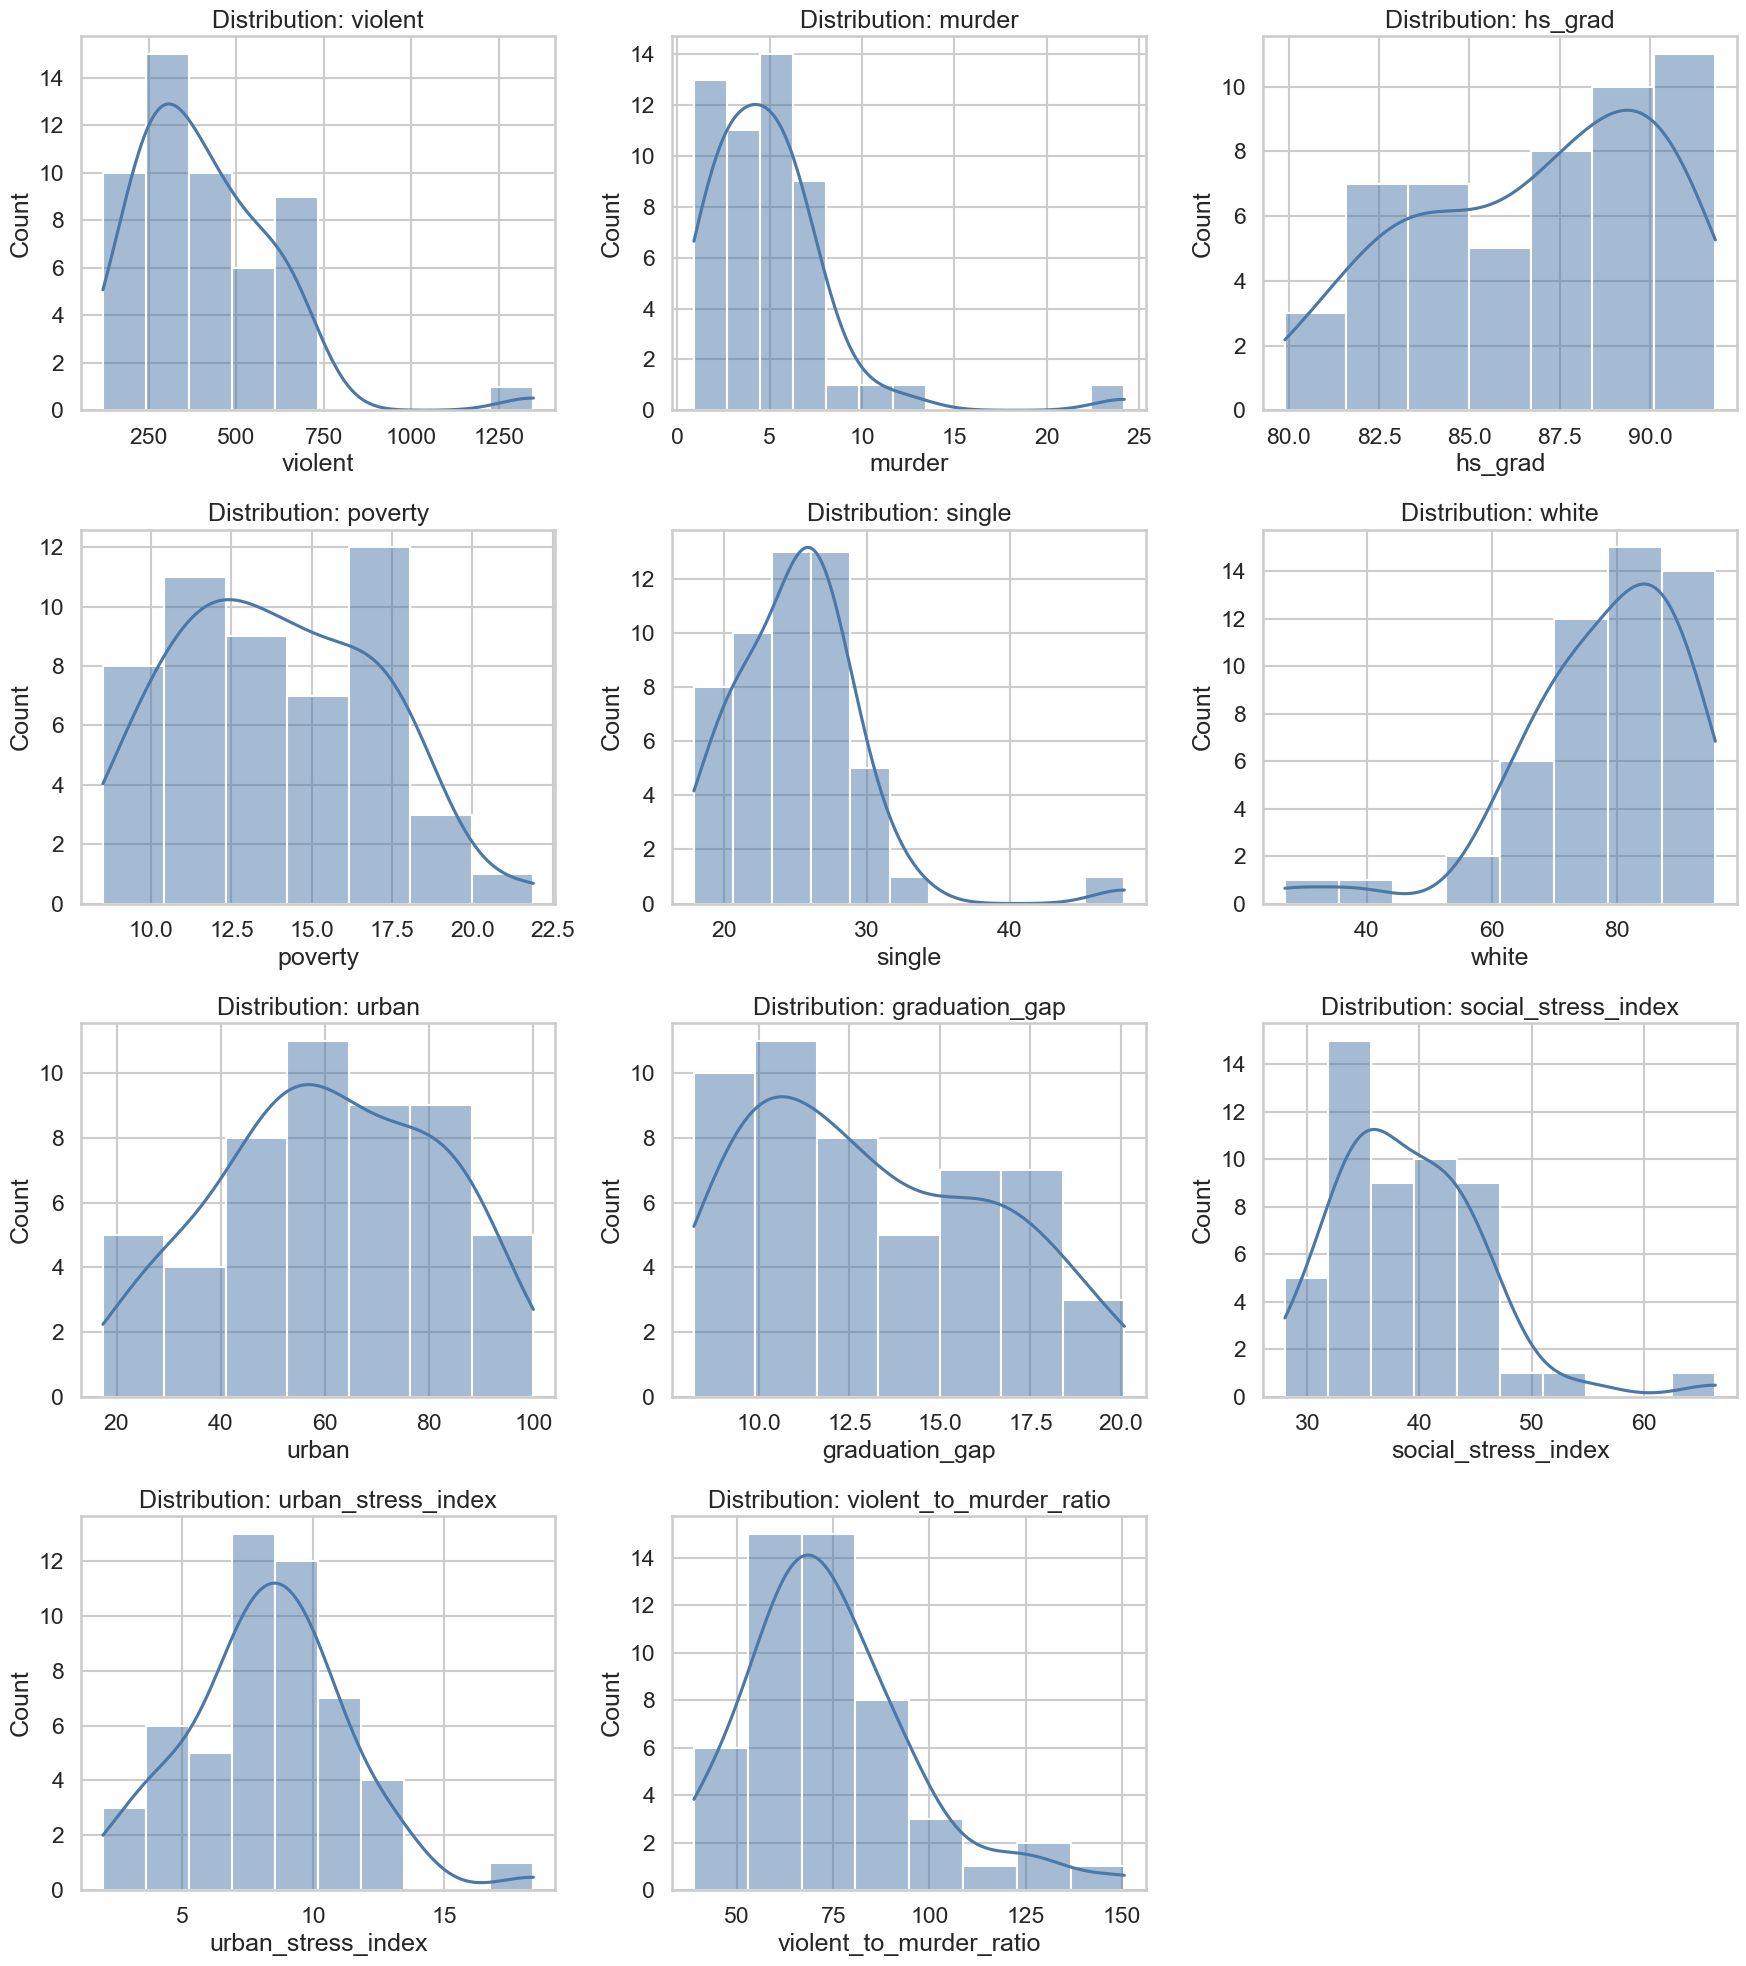

In [8]:
# Numeric columns (excluding the ID-like 'state') - we remove non-numeric columns
num_cols = raw.columns.drop("state").tolist()

display(raw[num_cols].describe().T)

# Histograms
n = len(num_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes = axes.flatten()

for i, c in enumerate(num_cols):
    sns.histplot(raw[c], kde=True, ax=axes[i], color="#4C78A8")
    axes[i].set_title(f"Distribution: {c}")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

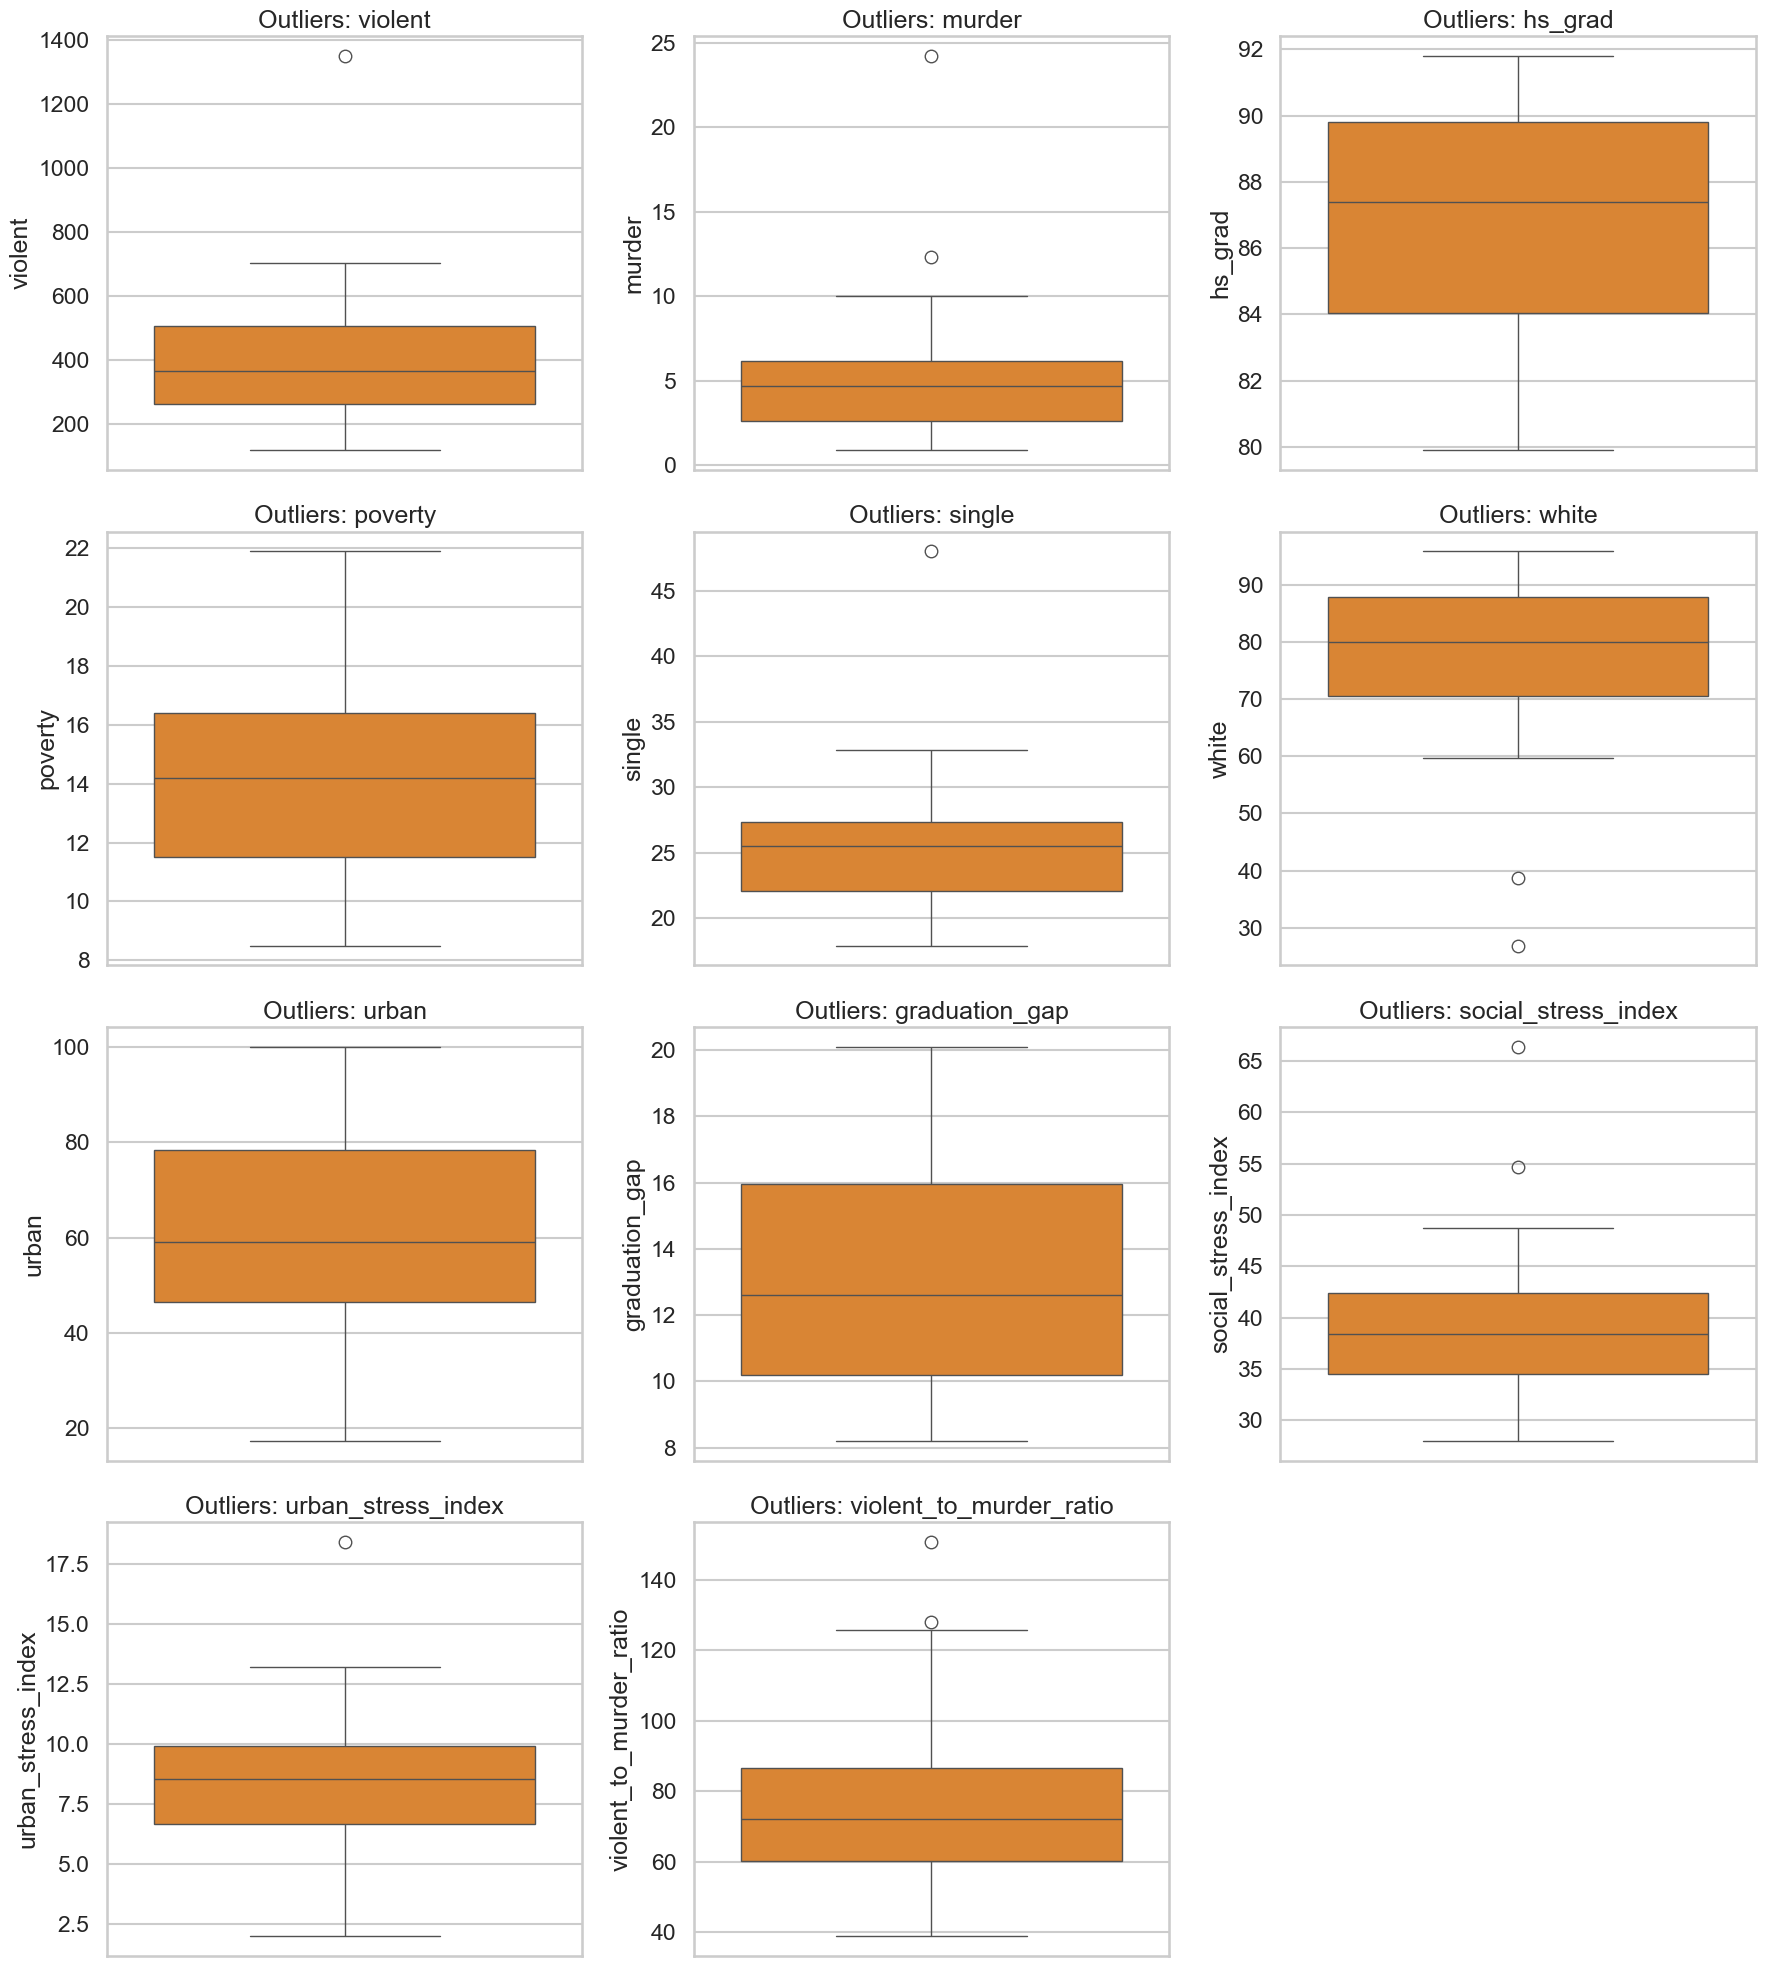

In [9]:
# Boxplots to visualize outliers
n = len(num_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes = axes.flatten()

for i, c in enumerate(num_cols):
    sns.boxplot(y=raw[c], ax=axes[i], color="#F58518")
    axes[i].set_title(f"Outliers: {c}")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

# 6- EDA (Bivariate)

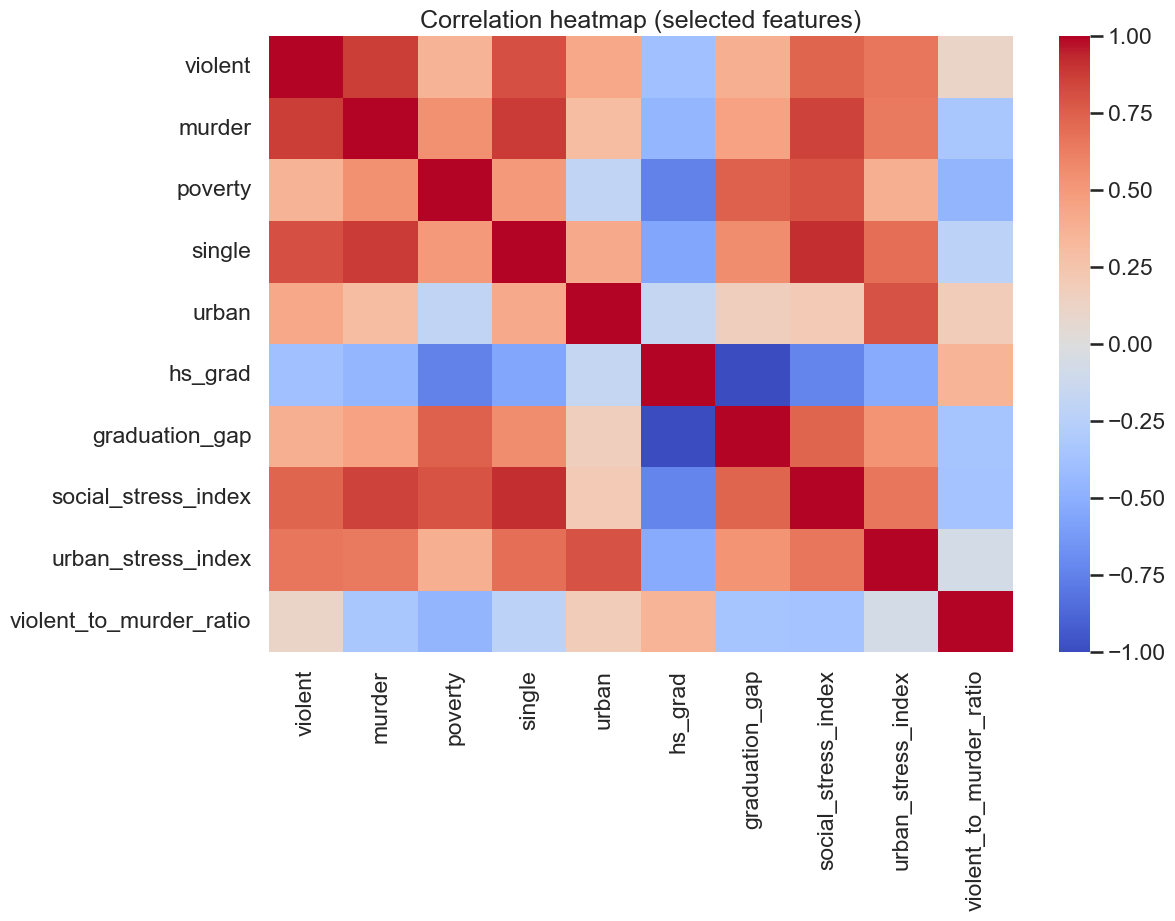

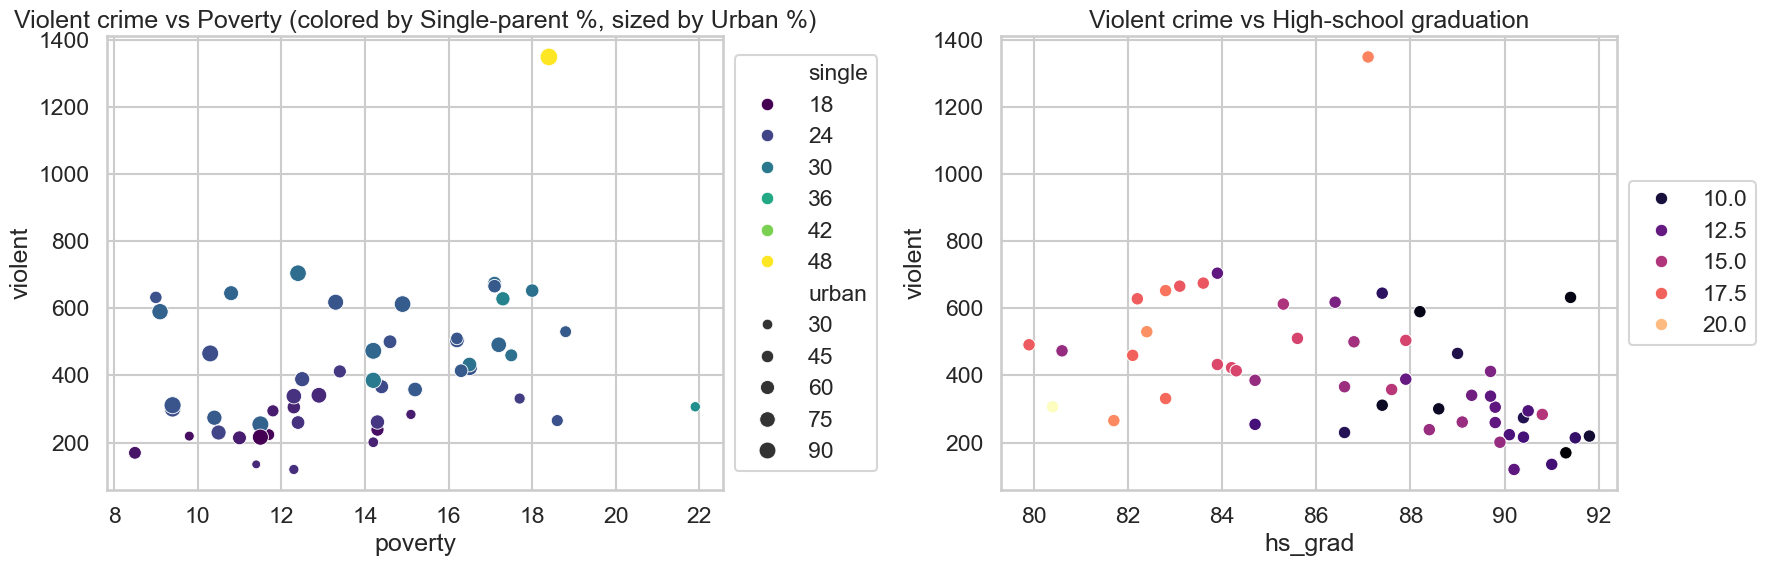

In [10]:
selected = [
    "violent",
    "murder",
    "poverty",
    "single",
    "urban",
    "hs_grad",
    "graduation_gap",
    "social_stress_index",
    "urban_stress_index",
    "violent_to_murder_ratio",
]

plt.figure(figsize=(12, 8))
sns.heatmap(raw[selected].corr(numeric_only=True), cmap="coolwarm", center=0, annot=False)
plt.title("Correlation heatmap (selected features)")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.scatterplot(data=raw, x="poverty", y="violent", hue="single", size="urban", palette="viridis", ax=axes[0])
axes[0].set_title("Violent crime vs Poverty (colored by Single-parent %, sized by Urban %)")
axes[0].legend(loc="center left", bbox_to_anchor=(1, 0.5))

sns.scatterplot(data=raw, x="hs_grad", y="violent", hue="poverty", palette="magma", ax=axes[1])
axes[1].set_title("Violent crime vs High-school graduation")
axes[1].legend(loc="center left", bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

## 1. Violent crime relationships

👉 violent is strongly related to:

murder ✅

single ✅

social_stress_index ✅

urban_stress_index ✅

Meaning:
Higher stress, more single-parent households → higher violent crime

# 2. Poverty relationships

👉 poverty is strongly related to:

social_stress_index

graduation_gap

single

Meaning:
Higher poverty → more stress, more inequality, more crime risk

# 🔵 3. Education (VERY IMPORTANT)

👉 hs_grad has negative correlation with:

violent ❌

murder ❌

poverty ❌

social_stress_index ❌

Meaning:
Higher education → lower crime and lower poverty

👉 This is one of your strongest insights


# # 4. Stress indexes

👉 social_stress_index and urban_stress_index are highly correlated

Meaning:
Areas with high stress tend to have higher crime
🔵 5. Graduation gap